# Understanding `approxcdf`'s bivariate-normal approximation (Tsay & Ke, 2021)

This notebook explains the fast bivariate-normal CDF approximation we can drop in
for the hot spot of the spatial-BMCD pairwise MLE, and then checks that it
actually works.

Where the cost comes from: inference (`mle_sigma_pairwise*`) maximises a pairwise
composite likelihood, and inside its double `for j,k` loop every pair needs

$$q_\text{joint}=\Phi_2\!\left(z_{j},\,z_{k};\,\rho\right)=P(Z_1<z_j,\,Z_2<z_k),$$

the standard bivariate-normal CDF. Right now `phi2` in `spatial_model.py` gets it
by building a fresh `scipy.stats.multivariate_normal` object on every call: exact,
but slow once you call it millions of times.

The idea from Tsay & Ke (2021) is to replace that exact CDF with a branch-free
closed-form approximation built from a single `exp`/`erf` expression, the paper's
$F_\text{app}(p,q;\rho)$ of Theorem 1 (here $p=z_j$, $q=z_k$). It is accurate to
about $10^{-3}$, pulls in no extra dependency, and being closed-form in $\rho$ it
vectorises over the per-pair $\rho$.

---

### One approximation, two implementations

This is the part that trips people up. The code ships two functions
(`bvn_teaching` in §3 and `bvn_tsay` in §4), and it is easy to assume they are two
different approximations of different quality. They are not.

- There is a single approximation step in the whole method: replace the error
  function by a fitted curve, $\operatorname{erf}(x)\approx g(x)=1-e^{c_1x+c_2x^2}$
  (equivalently, replace the inner normal CDF $\Phi$ by $\Phi_\text{approx}$). See §2.
- Everything after that is exact algebra: plug $\Phi_\text{approx}$ into the
  one-dimensional integral (§1) and integrate in closed form. The result is
  Theorem 1's $F_\text{app}$. There is no second approximation anywhere.
- That closed form is then *evaluated* two ways, and that is the only difference
  between §3 and §4:

| implementation | what it is | when you'd read / use it |
|---|---|---|
| `bvn_teaching` (§3) | does the integral live, generically, the readable way | to understand & audit the method |
| `bvn_tsay` (§4) | the same integral pre-solved on paper (Theorem 1's 5 cases) and vectorised in NumPy | to run it fast inside the MLE |

So §3 and §4 return the same number (§5 checks this to $\sim10^{-15}$); §4 is just
§3's integral with the pencil-and-paper work already done. It helps to keep two
levels apart:

| level | object | symbol | notebook |
|---|---|---|---|
| ingredient | the one approximation | $\Phi_\text{approx}\approx\Phi$ &nbsp;($g\approx\operatorname{erf}$) | `Phi_approx` (§2) |
| result | its exact closed-form integral | $F_\text{app}(p,q;\rho)\approx\Phi_2$ | `bvn_teaching` (§3), `bvn_tsay` (§4) |

---

The notebook is in two parts:

- Part 1 — Understand + Verify: what the approximation actually does (one idea, one
  plot, two readable kernels), the construction that turns that one idea into
  Theorem 1, and a check that it matches `scipy`.
- Part 2 — Speed + MLE check: how much faster it is, and confirmation that the
  estimated $\hat\sigma$ barely moves.

| method | accuracy vs scipy | vectorises over per-pair $\rho$? | dependency |
|---|---|---|---|
| `phi2` (scipy, current) | exact (baseline) | no | scipy |
| Tsay–Ke approximation (this nb) | $\sim10^{-3}$ | yes | none |

In [1]:
import sys, pathlib, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import multivariate_normal, norm
from scipy.optimize import minimize_scalar

_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'article_code').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import spatial_bmcd.spatial_model as sm
from spatial_bmcd.spatial_model import (
    phi2, build_C_from_sigma, simulate_history, mle_sigma_pairwise,
)

rng = np.random.default_rng(0)
SQRT2 = math.sqrt(2.0)
pd.set_option('display.float_format', lambda v: f'{v:.6g}')
print('numpy', np.__version__, '| scipy phi2 baseline ready')

numpy 2.3.5 | scipy phi2 baseline ready


# Part 1 — Understand + Verify

## 1. The quantity, and the exact identity it is built on

We need the bivariate-normal CDF $\Phi_2(p,q;\rho)=P(X_1<p,\,X_2<q)$ for standard
normals with correlation $\rho$, the paper's Eq. (1) (Tsay & Ke, 2021). In our case
the two upper limits $p,q$ are the z-scores $z_j,z_k$.

Conditioning on $X_2=\nu$ turns this into an exact single integral (paper Eq. (4),
rewritten with the substitution of Eq. (5)):

$$\Phi_2(p,q;\rho)=\int_{-\infty}^{q}\Phi\!\big(a\nu+b\big)\,\varphi(\nu)\,d\nu,
\qquad a=\frac{-\rho}{\sqrt{1-\rho^2}},\quad b=\frac{p}{\sqrt{1-\rho^2}},$$

where $\varphi,\Phi$ are the standard-normal pdf/cdf and $\nu$ is the integration
variable. Nothing is approximated yet, this identity is exact. The integrand holds
the inner univariate CDF $\Phi(a\nu+b)$; everything else ($\varphi$, the limits) is
elementary, so the only hard part is that inner $\Phi$.

This integral is where the whole method happens. The approximation in §2 touches
only that inner $\Phi$; carrying it through the integral (§3) gives the closed form
$F_\text{app}$. Nothing else on this line ever changes.

> Notation follows the paper. $\Phi_2(p,q;\rho)$, the integration variable $\nu$,
> and $a=-\rho/\sqrt{1-\rho^2}$, $b=p/\sqrt{1-\rho^2}$ are exactly Eqs. (1), (4),
> (5). In code the kernels take `(p, q, rho)`; the thin `phi2_*` wrappers accept
> the application's `(z1, z2, rho)` and set $p=z_1,\ q=z_2$.

## 2. The approximation — the only one in the whole method

The starting point (paper p. 4): Tsay & Ke approximate the error function by a
single Gaussian-type term with two fitted constants,

$$\operatorname{erf}(x)\;\approx\;g(x)=1-e^{c_1 x+c_2 x^2}\quad(x\ge 0),\qquad
c_1=-1.09500815,\ c_2=-0.75651138,$$

the constants of Theorem 1. (Both are negative; the paper's Theorem panel drops the
signs, but the Appendix confirms $c_1,c_2<0$, which is what makes $g(x)\to1$ as
$x\to\infty$.)

This is the same thing as approximating the inner normal CDF. Since
$\Phi(u)=\tfrac12\big[1+\operatorname{erf}(u/\sqrt2)\big]$ holds exactly (paper
Eqs. (6)–(7)), substituting $g$ for $\operatorname{erf}$ gives

$$\Phi(u)\;\approx\;\Phi_\text{approx}(u)=
\begin{cases}
1-\tfrac12\exp\!\big(\tfrac{c_1}{\sqrt2}\,u+\tfrac{c_2}{2}\,u^2\big), & u\ge 0,\\[4pt]
\phantom{1-}\tfrac12\exp\!\big(-\tfrac{c_1}{\sqrt2}\,u+\tfrac{c_2}{2}\,u^2\big), & u<0,
\end{cases}$$

(the two pieces reflect via $\Phi(u)=1-\Phi(-u)$). So "approximate $\operatorname{erf}$"
and "approximate the inner $\Phi$" are the same single approximation, just written
at two points of the derivation.

> This is the only approximation in the entire method. Everything in §3 and §4 (the
> integral, the completing-the-square, all five of Theorem 1's cases) is exact given
> $\Phi_\text{approx}$. So the method's accuracy is set entirely here, by how well
> $g$ matches $\operatorname{erf}$: the cell below shows $\Phi_\text{approx}$ tracks
> the true $\Phi$ to $\sim10^{-3}$, and that same $\sim10^{-3}$ is the error we see
> for $F_\text{app}$ vs scipy in §5. Nothing downstream adds or removes error.

> Where do Theorem 1's five cases come from, then? $\Phi_\text{approx}$ is the
> ingredient; Theorem 1's closed form $F_\text{app}(p,q;\rho)$ is the result of
> plugging $\Phi_\text{approx}$ into the §1 integral and doing that integral
> analytically (complete the square $\to\operatorname{erf}$; paper Eq. (8) and
> Appendix). The five cases are just bookkeeping: the inner argument $a\nu+b$ changes
> sign at $\nu^\star=-b/a$, so the closed form depends on the sign of $a$ and on
> whether the upper limit $q$ sits below or above $\nu^\star$ (the sign of $aq+b$).
> One approximation, integrated once, written out as five sign-cases.
>
> | level | object | in this notebook |
> |---|---|---|
> | ingredient | $\Phi_\text{approx}(u)\approx\Phi(u)$ &nbsp;(= $g\approx\operatorname{erf}$) | `Phi_approx` (§2) |
> | result | $F_\text{app}(p,q;\rho)\approx\Phi_2$, 5 cases (Theorem 1) | `bvn_teaching` (§3) / `bvn_tsay*` (§4) |

max |Phi_approx - Phi| over [-4, 4] = 1.102e-03


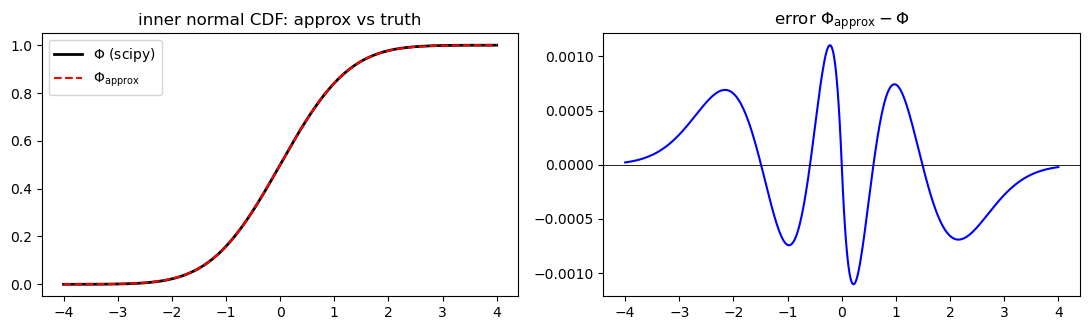

In [2]:
# Tsay-Ke fitted constants
C1 = -1.0950081470333
C2 = -0.75651138383854

def Phi_approx(u):
    """Tsay-Ke closed-form approximation of the standard normal CDF Phi(u)."""
    if u >= 0.0:
        return 1.0 - 0.5 * math.exp((C1 / SQRT2) * u + (C2 / 2.0) * u * u)
    return 0.5 * math.exp((-C1 / SQRT2) * u + (C2 / 2.0) * u * u)

uu = np.linspace(-4.0, 4.0, 401)
approx = np.array([Phi_approx(u) for u in uu])
true = norm.cdf(uu)
print(f'max |Phi_approx - Phi| over [-4, 4] = {np.max(np.abs(approx - true)):.3e}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(uu, true, 'k', lw=2, label=r'$\Phi$ (scipy)')
ax[0].plot(uu, approx, 'r--', lw=1.5, label=r'$\Phi_{\rm approx}$')
ax[0].set_title('inner normal CDF: approx vs truth'); ax[0].legend()
ax[1].plot(uu, approx - true, 'b'); ax[1].set_title(r'error $\Phi_{\rm approx}-\Phi$')
ax[1].axhline(0, color='k', lw=0.6)
plt.tight_layout(); plt.show()

## 3. Carrying the approximation through the integral → $F_\text{app}$ (the construction)

This is the core of the method. We take the §1 integral, drop in $\Phi_\text{approx}$
from §2, and integrate it exactly. The point of this section is that there is
nothing exotic going on: it is one complete-the-square done in closed form, and
`bvn_teaching` below does exactly that, live, on every call.

### 3.1 The integrand becomes a Gaussian

On each side of $u=0$, $\Phi_\text{approx}(u)$ is just $\tfrac12 e^{\text{quadratic}}$
(plus a constant $1$ on the $u\ge0$ side). Writing $u=a\nu+b$, $\beta=\tfrac{c_2}{2}$,
and $\text{slope}=\pm\tfrac{c_1}{\sqrt2}$, the "exp part" of the integrand is

$$\varphi(\nu)\cdot\tfrac12 e^{\,\text{slope}\cdot u+\beta u^2}
=\tfrac12\cdot\tfrac{1}{\sqrt{2\pi}}\,e^{-\nu^2/2}\;e^{\,\text{slope}(a\nu+b)+\beta(a\nu+b)^2}.$$

A Gaussian ($e^{-\nu^2/2}$) times $e^{\text{quadratic in }\nu}$ is again a Gaussian,
which is the whole reason the integral closes in elementary form.

### 3.2 Substitute $u=a\nu+b$: collect the quadratic in $\nu$

Expanding $\text{slope}\,(a\nu+b)+\beta(a\nu+b)^2$ and grouping powers of $\nu$ gives
the exponent $R+P\nu+Q\nu^2$ with

$$\boxed{\,Q=\beta\,a^2,\qquad P=a\,(\text{slope}+2\beta b),\qquad R=\text{slope}\cdot b+\beta b^2\,}$$

which is exactly the three-line recipe in `bvn_teaching`'s inner `tail()`. So one
"side" of the split is the single integral

$$\int_{lo}^{hi}\varphi(\nu)\,e^{\,R+P\nu+Q\nu^2}\,d\nu .$$

### 3.3 Complete the square → `erf` (A&S 7.4.32)

Fold the $-\tfrac12\nu^2$ from $\varphi$ into the exponent and complete the square:

$$-\tfrac12\nu^2+Q\nu^2+P\nu+R
=-\underbrace{\big(\tfrac12-Q\big)}_{A}\big(\nu-\underbrace{\tfrac{P}{2A}}_{\mu}\big)^2
+\underbrace{\Big(R+\tfrac{P^2}{4A}\Big)}_{\text{expo}} .$$

The leftover constant `expo` comes out of the integral; the remaining
$\int_{lo}^{hi}e^{-A(\nu-\mu)^2}d\nu$ is a plain Gaussian, equal to
$\tfrac{\sqrt\pi}{2\sqrt A}\big[\operatorname{erf}(\sqrt A(hi-\mu))-\operatorname{erf}(\sqrt A(lo-\mu))\big]$.
Collecting the $\tfrac{1}{\sqrt{2\pi}}$ prefactor gives the closed form

$$\int_{lo}^{hi}\varphi(\nu)\,e^{\,R+P\nu+Q\nu^2}\,d\nu
=\frac{e^{\,\text{expo}}}{2\sqrt{2A}}\,
\Big[\operatorname{erf}\!\big(\sqrt A\,(hi-\mu)\big)-\operatorname{erf}\!\big(\sqrt A\,(lo-\mu)\big)\Big],
\qquad A=\tfrac12-Q,\ \ \mu=\tfrac{P}{2A},\ \ \text{expo}=R+\tfrac{P^2}{4A}.$$

This is A&S 7.4.32 (paper Appendix). It is implemented verbatim as `_gauss_expquad`;
read the helper as this one equation, symbol for symbol:

| math | `_gauss_expquad` line | role |
|---|---|---|
| $A=\tfrac12-Q$ | `A = 0.5 - Q` | curvature of the completed square (need $A>0$, i.e. $Q<\tfrac12$) |
| $\mu=P/2A$ | `mu = P / (2.0 * A)` | centre of the Gaussian |
| $\text{expo}=R+P^2/4A$ | `expo = R + P * P / (4.0 * A)` | the constant pulled out front (kept bounded as $|\rho|\to1$) |
| $\tfrac{1}{2\sqrt{2A}}e^{\text{expo}}[\operatorname{erf}-\operatorname{erf}]$ | `math.exp(expo)/(2*sqrt(2*A))*(erf(...)-erf(...))` | the Gaussian integrated to `erf` |

> What "complete the square *in code*" means: `_gauss_expquad` recomputes `A, mu,
> expo` from whatever `(P, Q, R)` it is handed, every call. It is a generic
> Gaussian×exp integrator and never "knows" it is dealing with $c_1,c_2$. §4 does the
> opposite: the same algebra worked out once, by hand, with $c_1,c_2$ already
> substituted, so there is nothing left to recompute.

### 3.4 The split at $\nu^\star$, and the three terms `bvn_teaching` returns

The one thing 3.3 leaves open is *where* each side-form of $\Phi_\text{approx}$
applies. The inner argument $u=a\nu+b$ crosses zero at

$$\nu^\star=-\,b/a,$$

so the $u<0$ exp-tail applies below $\nu^\star$ and the $u\ge0$ form (the
$1-\tfrac12 e^{(\cdot)}$) applies above it. Splitting $\int_{-\infty}^{q}$ there is
the paper's Eq. (8) (its two integrals $A,B$). For the representative case $a>0$ with
$q>\nu^\star$ (the range straddles the split), the integral is the sum of three
elementary pieces, and this is literally what `bvn_teaching` returns:

$$
F_\text{app}=
\underbrace{\big(\Phi(q)-\Phi(\nu^\star)\big)}_{\textbf{(i) the constant }1}
\;+\;
\underbrace{\tfrac12\!\int_{-\infty}^{\nu^\star}\!\!\varphi\,e^{\,\text{slope}_-\,u+\beta u^2}}_{\textbf{(ii) the }u<0\text{ tail}}
\;-\;
\underbrace{\tfrac12\!\int_{\nu^\star}^{q}\!\!\varphi\,e^{\,\text{slope}_+\,u+\beta u^2}}_{\textbf{(iii) the }u\ge0\text{ tail}}
$$

- (i) is the $\int\varphi\cdot 1\,d\nu$ from the "$1$" in $1-\tfrac12e^{(\cdot)}$ on
  the $u\ge0$ side, a plain CDF difference, the `Phi(q) - Phi(nu_star)` line (the
  only place the readable kernel calls scipy's `norm.cdf`).
- (ii) and (iii) are two calls to `_gauss_expquad` (via `tail`), i.e. the closed form
  of 3.3 with the two limit-pairs $(-\infty,\nu^\star)$ and $(\nu^\star,q)$.

The full map from paper to code (no algebra re-derived, just the route `bvn_teaching`
walks):

| step | paper | code |
|---|---|---|
| 1. start | Eq. (5): $\int_{-\infty}^{q}\Phi(a\nu+b)\varphi(\nu)\,d\nu$ | the §1 identity |
| 2. expand inner $\Phi$ | Eqs. (6)–(7): $\Phi=\tfrac12+\tfrac12\operatorname{erf}$ | `Phi_approx`'s two pieces (§2) |
| 3. split at sign change | Eq. (8): two integrals $A,B$ | `nu_star`, the two `tail(...)` calls |
| 4. approximate + integrate | $g\approx\operatorname{erf}$, then A&S 7.4.32 | `_gauss_expquad` |
| 5. collect into cases | Theorem 1 (5 cases) | §4 `bvn_tsay*` — pre-collected; `bvn_teaching` instead re-runs 3–4 live |

Worth keeping the labels (i)/(ii)/(iii) in mind: in §4 we'll see that Theorem 1's
Case 1 is the same three terms, just pre-simplified, and the demo cell matches them
one by one.

In [3]:
def _gauss_expquad(P, Q, R, lo, hi):
    """Closed form of  integral_lo^hi  phi(nu) * exp(R + P*nu + Q*nu^2) d nu   (needs Q < 1/2).

    This is the §3.3 equation = A&S 7.4.32 (Gaussian x exp -> erf). Completing the
    square turns phi(nu)*exp(R + P nu + Q nu^2) into  exp(expo) * exp(-A (nu-mu)^2),
    so the integral is a prefactor * (erf(.) - erf(.)):

        A    = 1/2 - Q            curvature of the completed square (need A > 0)
        mu   = P / (2A)           centre of the Gaussian
        expo = R + P^2 / (4A)     constant pulled out front (stays bounded as |rho| -> 1)

    It is a *generic* integrator: it recomputes A, mu, expo from whatever (P,Q,R)
    arrive and never references c1, c2. (Contrast §4, where this same algebra is
    pre-done by hand with c1, c2 already substituted.)
    """
    A = 0.5 - Q
    mu = P / (2.0 * A)
    expo = R + P * P / (4.0 * A)               # bounded combined exponent
    return math.exp(expo) / (2.0 * math.sqrt(2.0 * A)) * (
        math.erf(math.sqrt(A) * (hi - mu)) - math.erf(math.sqrt(A) * (lo - mu)))

def bvn_teaching(p, q, rho):
    """Phi_2(p, q; rho) = F_app, computed the readable way (the §3 construction, live).

    Essential logic (this *is* the method, un-pre-expanded):
      1. a, b are Eq.(5); the inner arg u = a*nu + b crosses 0 at nu_star = -b/a.
      2. Split the integral there: below nu_star the u<0 exp-tail of Phi_approx
         applies, above it the u>=0 form (1 - 1/2 exp). -> paper Eq.(8).
      3. Each side is one `tail(...)` = `_gauss_expquad` (the §3.3 closed form).
         The "1" in (1 - 1/2 exp) integrates to a plain CDF difference, Phi(q)-Phi(nu*).
    Returns the SAME F_app as the fast port `bvn_tsay*` (§4); see §5 (~1e-15).
    The three returned terms are labelled (i)/(ii)/(iii) to match Theorem 1 Case 1 in §4.
    """
    if abs(rho) <= 1e-14:                       # Theorem 1 case 2 (rho=0): independent -> product of marginals
        return float(norm.cdf(p) * norm.cdf(q))
    denom = math.sqrt(1.0 - rho * rho)
    a = -rho / denom                            # Eq.(5): a = -rho / sqrt(1-rho^2)
    b = p / denom                               # Eq.(5): b = p / sqrt(1-rho^2)
    beta = C2 / 2.0                             # u^2 coefficient (same on both sides), u = a*nu+b
    Q = beta * a * a                            # -> nu^2 coefficient after substituting u = a*nu+b (§3.2)

    def tail(slope, lo, hi):
        # one side of the Eq.(8) split: integral of phi(nu) * g-tail(a nu+b) over [lo, hi].
        # (P, Q, R) is the §3.2 recipe; _gauss_expquad does the §3.3 complete-the-square.
        P = a * (slope + 2.0 * beta * b)        # nu^1 coefficient
        R = slope * b + beta * b * b            # nu^0 coefficient
        return _gauss_expquad(P, Q, R, lo, hi)

    nu_star = -b / a                            # Eq.(8) split point nu*: inner argument a*nu+b crosses 0 here
    slope_pos, slope_neg = C1 / SQRT2, -C1 / SQRT2   # exp slope on the u>=0 / u<0 side
    Phi = norm.cdf
    if a > 0:                                   # a*nu+b: negative below nu_star, positive above
        if q <= nu_star:                        # whole range has u < 0  (Theorem 1 case 3 / branch B)
            return 0.5 * tail(slope_neg, -math.inf, q)
        # straddles nu_star (Theorem 1 case 1 / branch A): the three terms of §3.4
        return (0.5 * tail(slope_neg, -math.inf, nu_star)                  # (ii) u < 0 tail
                + (float(Phi(q)) - float(Phi(nu_star)))                    # (i)  the constant "1": Phi(q) - Phi(nu*)
                - 0.5 * tail(slope_pos, nu_star, q))                       # (iii) u >= 0 tail
    else:                                       # a < 0: positive below nu_star, negative above
        if q <= nu_star:                        # whole range has u >= 0  (Theorem 1 case 4 / branch C)
            return float(Phi(q)) - 0.5 * tail(slope_pos, -math.inf, q)     # (i)+(iii): "1" up to q minus u>=0 tail
        # straddles nu_star (Theorem 1 case 5 / branch D)
        return (float(Phi(nu_star)) - 0.5 * tail(slope_pos, -math.inf, nu_star)  # (i)+(iii) on the u >= 0 part
                + 0.5 * tail(slope_neg, nu_star, q))                       # (ii) u < 0 tail

def phi2_teaching(z1, z2, rho):
    """Readable drop-in matching phi2's signature (same clip); here p=z1, q=z2."""
    rho = float(np.clip(rho, -0.999999, 0.999999))
    return float(bvn_teaching(z1, z2, rho))

print('teaching:', phi2_teaching(0.5, -0.3, 0.7), '| scipy:', phi2(0.5, -0.3, 0.7))

teaching: 0.35676831101770795 | scipy: 0.3567836347968547


## 4. The fast production port — the same $F_\text{app}$, pre-solved and vectorised

> Worth reading before the code, since it clears up the main confusion: `bvn_tsay`
> is not a second, lower-quality approximation. It is the identical $F_\text{app}$
> from §3, with the §3 integral already solved on paper into Theorem 1's five
> closed-form cases, then written branch-free for NumPy. Briefly: `bvn_teaching`
> *runs* the integral, `bvn_tsay` *evaluates the answer*. Same number (§5 confirms
> to $\sim10^{-15}$); the port is just faster and vectorises.

So why keep the unreadable version around at all? Speed. The MLE calls $\Phi_2$ on
millions of pairs, and the only way to make that a single NumPy array op is a
branch-free arithmetic expression, which is exactly what pre-collecting the integral
into Theorem 1's cases buys. The cryptic names (`a_sq_c1`, `twicea_s`, `t1`, …) are
just the §3.3 building blocks frozen with $c_1,c_2$ already substituted.

### 4.1 The bridge: Theorem 1 Case 1 = `bvn_teaching`'s three terms

Case 1 ($a>0,\ aq+b\ge0$, the straddle case of §3.4, branch A in code) reads

$$
F_\text{app}=
\underbrace{\tfrac12\!\Big[\operatorname{erf}\tfrac{q}{\sqrt2}+\operatorname{erf}\tfrac{b}{\sqrt2\,a}\Big]}_{\textbf{(i)}}
+\underbrace{\tfrac{1}{4\sqrt{1-a^2c_2}}\,e^{\frac{a^2c_1^2-2\sqrt2\,bc_1+2b^2c_2}{4(1-a^2c_2)}}\!\Big[1-\operatorname{erf}\tfrac{\sqrt2\,b-a^2c_1}{2a\sqrt{1-a^2c_2}}\Big]}_{\textbf{(ii)}}
-\underbrace{\tfrac{1}{4\sqrt{1-a^2c_2}}\,e^{\frac{a^2c_1^2+2\sqrt2\,bc_1+2b^2c_2}{4(1-a^2c_2)}}\!\Big[\operatorname{erf}(\cdots)+\operatorname{erf}\tfrac{a^2c_1+\sqrt2\,b}{2a\sqrt{1-a^2c_2}}\Big]}_{\textbf{(iii)}}
$$

and it is term-for-term the three pieces `bvn_teaching` returns (§3.4):

| Case 1 group (port / paper) | `bvn_teaching` term | why equal |
|---|---|---|
| (i) $\tfrac12[\operatorname{erf}\tfrac{q}{\sqrt2}+\operatorname{erf}\tfrac{b}{\sqrt2 a}]$ | `Phi(q) - Phi(nu_star)` | exact identity ⓐ below |
| (ii) prefactor·$e^{(\cdots)}$·$[1-\operatorname{erf}]$ | `0.5 * tail(slope_neg, -inf, nu_star)` | `_gauss_expquad` with limits $(-\infty,\nu^\star)$, simplified |
| (iii) prefactor·$e^{(\cdots)}$·$[\operatorname{erf}+\operatorname{erf}]$ | `0.5 * tail(slope_pos, nu_star, q)` | `_gauss_expquad` with limits $(\nu^\star,q)$, simplified |

Two anchors you can check by hand pin the bridge down:

- ⓐ the (i) identity. With $\Phi(x)=\tfrac12\big(1+\operatorname{erf}\tfrac{x}{\sqrt2}\big)$ and $\nu^\star=-b/a$,
$$\Phi(q)-\Phi(\nu^\star)=\Phi(q)-\Phi\!\big(\tfrac{-b}{a}\big)
=\tfrac12\operatorname{erf}\tfrac{q}{\sqrt2}+\tfrac12\operatorname{erf}\tfrac{b}{\sqrt2\,a}\quad\textbf{(exactly group (i))}.$$
- ⓑ the prefactor. From §3.3, $A=\tfrac12-Q=\tfrac12-\tfrac{c_2}{2}a^2=\tfrac12(1-a^2c_2)$, so $\sqrt{2A}=\sqrt{1-a^2c_2}$, and `bvn_teaching`'s $\tfrac12\cdot\tfrac{1}{2\sqrt{2A}}=\dfrac{1}{4\sqrt{1-a^2c_2}}$, exactly the port's prefactor.

So the port's mystery names are nothing new, they are $A,\mu,\text{expo}$ of
$\,$`_gauss_expquad`$\,$ after substituting $Q=\tfrac{c_2}{2}a^2$ etc.:

$$\underbrace{s=\sqrt{1-a^2c_2}}_{=\sqrt{2A}},\qquad
\underbrace{\text{temp}=\tfrac{1}{4s}}_{\text{prefactor}},\qquad
\underbrace{e^{(t_1\mp t_2)/t_3}}_{=\,e^{\text{expo}}},\qquad
\underbrace{\text{erf}(\cdots/(2s)),\ \text{erf}(\cdots/\text{twicea\_s})}_{=\,\operatorname{erf}(\sqrt A(\text{limit}-\mu))}.$$

The code cell carries these labels inline; the cell after it proves the bridge
numerically, computing each of (i)/(ii)/(iii) both ways and showing they match.

> Paper link. Branches map to Theorem 1 by the sign of $a$ and of $aq+b$ (the inner
> argument at the upper limit $\nu=q$, `aqb` in code): A = case 1 ($a>0,\ aq+b\ge0$),
> B = case 3 ($a>0,\ aq+b<0$), C = case 4 ($a<0,\ aq+b\ge0$), D = case 5
> ($a<0,\ aq+b<0$); the $\rho=0$ shortcut is case 2. It is bit-faithful to the C
> kernel `norm_cdf_2d_vfast` of the `approxcdf` package (David Cortes).

In [4]:
# approxcdf src/other.cpp constants (Tsay & Ke 2021, Theorem 1)
C1 = -1.0950081470333
C2 = -0.75651138383854

def _PHI(x):  # standard normal CDF, scalar
    return 0.5 * math.erfc(-x / SQRT2)

def bvn_tsay_scalar(p, q, rho):
    # Faithful scalar port of approxcdf's norm_cdf_2d_vfast = Theorem 1's F_app(p, q; rho),
    # PRE-EXPANDED. This computes the *same* number as bvn_teaching (§3); it is just the §3
    # integral already solved on paper, so there is no split/integrate left to do at runtime.
    #
    # Selection (no math, pure bookkeeping):
    #   a, b are Eq.(5); aqb = a*q + b is the inner argument a*nu+b at the upper limit nu=q.
    #   sign(a) x sign(aqb) picks the case:  A=case1 (a>0,aqb>=0)   B=case3 (a>0,aqb<0)
    #                                        C=case4 (a<0,aqb>=0)   D=case5 (a<0,aqb<0);  rho=0 -> case2.
    #
    # The recurring blocks are the §3.3 complete-the-square pieces with c1,c2 substituted:
    #   s    = sqrt(1 - a^2*c2)        == sqrt(2A)            (A = 1/2 - Q, Q = (c2/2) a^2)
    #   temp = 1/(4s)                  == 0.5 * 1/(2 sqrt(2A))  (the prefactor, incl. bvn_teaching's 0.5)
    #   mx((t1 -/+ t2)/t3)             == exp(expo)           (expo = R + P^2/4A)
    #   me(... / (2s)), me(... / twicea_s) == erf(sqrt(A)*(limit - mu))
    # Branch A is annotated (i)/(ii)/(iii) to line up with bvn_teaching's three terms (§3.4);
    # the next cell verifies that correspondence numerically.
    if abs(rho) <= 1e-14:                       # Theorem 1 case 2 (rho=0): independence
        return _PHI(p) * _PHI(q)
    me = math.erf; mx = math.exp
    denom = math.sqrt(1.0 - rho * rho)
    a = -rho / denom; b = p / denom; aqb = a * q + b
    if a > 0:
        if aqb >= 0:
            # branch A = Theorem 1 case 1 (a > 0, a*q+b >= 0)  == bvn_teaching straddle case
            aa = a * a; a_sq_c1 = aa * C1; a_sq_c2 = aa * C2
            sqrt2b = SQRT2 * b; sqrt2q = SQRT2 * q
            s = math.sqrt(1.0 - a_sq_c2); twicea_s = 2.0 * a * s; temp = 1.0 / (4.0 * s)
            t1 = a_sq_c1 * C1 + 2.0 * b * b * C2; t2 = 2.0 * sqrt2b * C1; t3 = 4.0 - 4.0 * a_sq_c2
            return (0.5 * (me(q / SQRT2) + me(b / (SQRT2 * a)))                                       # (i)  Phi(q)-Phi(nu*)
                    + temp * mx((t1 - t2) / t3) * (1.0 - me((sqrt2b - a_sq_c1) / twicea_s))           # (ii) u<0 tail
                    - temp * mx((t1 + t2) / t3) * (me((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 - a * C1) / (2.0 * s))
                                                   + me((a_sq_c1 + sqrt2b) / twicea_s)))              # (iii) u>=0 tail
        else:
            # branch B = Theorem 1 case 3 (a > 0, a*q+b < 0)
            sqrt2b = SQRT2 * b; sqrt2q = SQRT2 * q; a_sq_c2 = a * a * C2
            r = 1.0 - a_sq_c2; s = math.sqrt(r); a_c1 = a * C1
            return ((1.0 / (4.0 * s)) * mx((a_c1 * a_c1 - 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
                    * (1.0 + me((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))))
    else:
        if aqb >= 0:
            # branch C = Theorem 1 case 4 (a < 0, a*q+b >= 0)
            sqrt2b = SQRT2 * b; a_sq_c2 = a * a * C2; r = 1.0 - a_sq_c2; s = math.sqrt(r)
            a_c1 = a * C1; sqrt2_q = SQRT2 * q
            return (0.5 + 0.5 * me(q / SQRT2)
                    - (1.0 / (4.0 * s)) * mx((a_c1 * a_c1 + 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
                    * (1.0 + me((sqrt2_q - sqrt2_q * a_sq_c2 - sqrt2b * a * C2 - a_c1) / (2.0 * s))))
        else:
            # branch D = Theorem 1 case 5 (a < 0, a*q+b < 0)
            sqrt2a = SQRT2 * a; sqrt2b = SQRT2 * b; a_sq_c2 = a * a * C2
            r = 1.0 - a_sq_c2; s = math.sqrt(r); a_c1 = a * C1; temp = 1.0 / (4.0 * s)
            t1 = a_c1 * a_c1 + 2.0 * b * b * C2; t2 = 2.0 * sqrt2b * C1; t3 = 4.0 * r; sqrt2_q = SQRT2 * q
            return (0.5 - 0.5 * me(b / sqrt2a)
                    - temp * mx((t1 + t2) / t3) * (1.0 - me((sqrt2b + a * a_c1) / (2.0 * a * s)))
                    + temp * mx((t1 - t2) / t3) * (me((sqrt2_q - sqrt2_q * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))
                                                   + me((sqrt2b - a * a_c1) / (2.0 * a * s))))

def bvn_tsay(p, q, rho, indep_tol=1e-14):
    # vectorised port of norm_cdf_2d_vfast; computes Theorem 1's F_app over arrays, all 4 branches by mask
    p, q, rho = np.broadcast_arrays(np.asarray(p, float), np.asarray(q, float), np.asarray(rho, float))
    with np.errstate(all='ignore'):
        denom = np.sqrt(1.0 - rho * rho)
        a = -rho / denom; b = p / denom; aqb = a * q + b    # Eq.(5) a,b; aqb = inner arg at upper limit nu=q
        aa = a * a; sqrt2b = SQRT2 * b; sqrt2q = SQRT2 * q
        a_sq_c1 = aa * C1; a_sq_c2 = aa * C2
        r = 1.0 - a_sq_c2; s = np.sqrt(r); temp = 1.0 / (4.0 * s); a_c1 = a * C1; twicea_s = 2.0 * a * s
        # branch A: Theorem 1 case 1 (a>0, aqb>=0)
        t1A = a_sq_c1 * C1 + 2.0 * b * b * C2; t2A = 2.0 * sqrt2b * C1; t3A = 4.0 * r
        A = (0.5 * (erf(q / SQRT2) + erf(b / (SQRT2 * a)))
             + temp * np.exp((t1A - t2A) / t3A) * (1.0 - erf((sqrt2b - a_sq_c1) / twicea_s))
             - temp * np.exp((t1A + t2A) / t3A) * (erf((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 - a * C1) / (2.0 * s))
                                                   + erf((a_sq_c1 + sqrt2b) / twicea_s)))
        # branch B: Theorem 1 case 3 (a>0, aqb<0)
        B = (temp * np.exp((a_c1 * a_c1 - 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
             * (1.0 + erf((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))))
        # branch C: Theorem 1 case 4 (a<=0, aqb>=0)
        Cc = (0.5 + 0.5 * erf(q / SQRT2)
              - temp * np.exp((a_c1 * a_c1 + 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
              * (1.0 + erf((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 - a_c1) / (2.0 * s))))
        # branch D: Theorem 1 case 5 (a<=0, aqb<0)
        t1D = a_c1 * a_c1 + 2.0 * b * b * C2; t2D = 2.0 * sqrt2b * C1; t3D = 4.0 * r
        D = (0.5 - 0.5 * erf(b / (SQRT2 * a))
             - temp * np.exp((t1D + t2D) / t3D) * (1.0 - erf((sqrt2b + a * a_c1) / (2.0 * a * s)))
             + temp * np.exp((t1D - t2D) / t3D) * (erf((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))
                                                   + erf((sqrt2b - a * a_c1) / (2.0 * a * s))))
        out = np.where(a > 0, np.where(aqb >= 0, A, B), np.where(aqb >= 0, Cc, D))
    indep = np.abs(rho) <= indep_tol           # Theorem 1 case 2 (rho=0): independence
    if np.any(indep):
        out = np.where(indep, norm.cdf(p) * norm.cdf(q), out)
    return out

def phi2_approxcdf(z1, z2, rho):
    # scalar drop-in for phi2 (same clip), pure-math kernel; here p=z1, q=z2
    rho = float(np.clip(rho, -0.999999, 0.999999))
    return bvn_tsay_scalar(z1, z2, rho)

def phi2_approxcdf_vec(z1, z2, rho):
    # array drop-in for phi2 (same clip), NumPy kernel; here p=z1, q=z2
    rho = np.clip(rho, -0.999999, 0.999999)
    return bvn_tsay(z1, z2, rho)

print('sample  port:', phi2_approxcdf(0.5, -0.3, 0.7),
      '| teaching:', phi2_teaching(0.5, -0.3, 0.7),
      '| scipy:', phi2(0.5, -0.3, 0.7))

sample  port: 0.35676831101770795 | teaching: 0.35676831101770795 | scipy: 0.3567836347968547


In [5]:
# --- The bridge, made concrete: Theorem 1 Case 1 (port, branch A) == bvn_teaching's 3 terms ---
# Pick one sample that lands in Case 1 (need a > 0 and aqb = a*q + b >= 0):
p, q, rho = 0.5, 0.8, -0.6
denom = math.sqrt(1.0 - rho * rho)
a = -rho / denom; b = p / denom; aqb = a * q + b
assert a > 0 and aqb >= 0, "sample must be in Theorem 1 Case 1 (branch A)"
nu_star = -b / a

# (1) bvn_teaching's three pieces, rebuilt here from the §3 recipe (same tail() as in §3).
beta = C2 / 2.0; Q = beta * a * a
slope_pos, slope_neg = C1 / SQRT2, -C1 / SQRT2
def tail(slope, lo, hi):                      # §3.2 (P,Q,R) recipe + §3.3 closed form
    P = a * (slope + 2.0 * beta * b); R = slope * b + beta * b * b
    return _gauss_expquad(P, Q, R, lo, hi)
teach_i   = float(norm.cdf(q) - norm.cdf(nu_star))   # (i)   the constant "1": Phi(q) - Phi(nu*)
teach_ii  = 0.5 * tail(slope_neg, -math.inf, nu_star)# (ii)  u < 0 tail
teach_iii = -0.5 * tail(slope_pos, nu_star, q)       # (iii) u >= 0 tail

# (2) Theorem 1 Case 1's three groups, read straight off branch A of bvn_tsay_scalar.
aa = a * a; a_sq_c1 = aa * C1; a_sq_c2 = aa * C2
sqrt2b = SQRT2 * b; sqrt2q = SQRT2 * q
s = math.sqrt(1.0 - a_sq_c2); twicea_s = 2.0 * a * s; temp = 1.0 / (4.0 * s)
t1 = a_sq_c1 * C1 + 2.0 * b * b * C2; t2 = 2.0 * sqrt2b * C1; t3 = 4.0 - 4.0 * a_sq_c2
paper_i   = 0.5 * (math.erf(q / SQRT2) + math.erf(b / (SQRT2 * a)))
paper_ii  = temp * math.exp((t1 - t2) / t3) * (1.0 - math.erf((sqrt2b - a_sq_c1) / twicea_s))
paper_iii = -temp * math.exp((t1 + t2) / t3) * (math.erf((sqrt2q - sqrt2q * a_sq_c2 - sqrt2b * a * C2 - a * C1) / (2.0 * s))
                                                + math.erf((a_sq_c1 + sqrt2b) / twicea_s))

bridge = pd.DataFrame({
    'term': ['(i)  Phi(q)-Phi(nu*)', '(ii) u<0 tail', '(iii) u>=0 tail', 'TOTAL = F_app'],
    'bvn_teaching (§3)': [teach_i, teach_ii, teach_iii, teach_i + teach_ii + teach_iii],
    'Theorem 1 Case 1 (§4)': [paper_i, paper_ii, paper_iii, paper_i + paper_ii + paper_iii],
})
bridge['|diff|'] = (bridge['bvn_teaching (§3)'] - bridge['Theorem 1 Case 1 (§4)']).abs()
print(f'sample: p={p}, q={q}, rho={rho}  ->  a={a:.4f}>0, aqb={aqb:.4f}>=0  (Case 1 / branch A)\n')
print(bridge.to_string(index=False))

# Each piece matches; and the two totals equal the actual kernels (not just each other).
assert (bridge['|diff|'] < 1e-12).all(), 'a Case-1 group does not match its bvn_teaching term!'
assert abs((teach_i + teach_ii + teach_iii) - bvn_teaching(p, q, rho)) < 1e-12
assert abs((paper_i + paper_ii + paper_iii) - bvn_tsay_scalar(p, q, rho)) < 1e-12
print('\nOK -- term by term, the readable integral (§3) IS Theorem 1 Case 1 (§4).')

sample: p=0.5, q=0.8, rho=-0.6  ->  a=0.7500>0, aqb=1.2250>=0  (Case 1 / branch A)

                term  bvn_teaching (§3)  Theorem 1 Case 1 (§4)      |diff|
(i)  Phi(q)-Phi(nu*)           0.585816               0.585816 1.11022e-16
       (ii) u<0 tail          0.0704957              0.0704957 4.16334e-17
     (iii) u>=0 tail          -0.164242              -0.164242 2.77556e-17
       TOTAL = F_app            0.49207                0.49207 1.66533e-16

OK -- term by term, the readable integral (§3) IS Theorem 1 Case 1 (§4).


## 5. Verify correctness against scipy

The previous cell checked the bridge at one point; this one checks it across a whole
grid and also measures the actual approximation error. Mesh $p,q\in[-3.5,3.5]$
against a range of $\rho$ and compare $F_\text{app}$ to
`scipy.stats.multivariate_normal(...).cdf` (the exact baseline). The three numbers
line up with the "one approximation, two implementations" picture:

- port vs scipy and teaching vs scipy $\sim10^{-3}$: this is the error of the method,
  and it comes entirely from §2's $g\approx\operatorname{erf}$; both implementations
  inherit the same $\sim10^{-3}$.
- teaching vs port $\sim10^{-15}$: this measures no error at all. It is the §4.1
  bridge at scale: the readable integral (§3) and the hand-collected Theorem 1
  formulas (§4) are the same $F_\text{app}$ everywhere, to machine precision. (Had §2
  used a worse $g$, the first two numbers would grow and this third one would not
  move, which is what "two implementations of one approximation" means in practice.)

> Paper link. The $\sim10^{-3}$ target is the accuracy reported in the paper's Table
> 1 (and Table 2), where the worst difference between $F_\text{app}$ and the exact CDF
> is to four decimal places.

port     vs scipy : max |d| = 5.824e-04   mean 5.01e-05
teaching vs scipy : max |d| = 5.824e-04   mean 5.01e-05
teaching vs port  : max |d| = 6.661e-16   (same closed form)
OK -- approximation ~1e-3 vs scipy; teaching == port to machine precision.


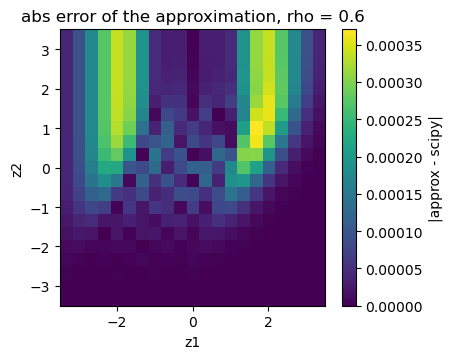

In [6]:
zs = np.linspace(-3.5, 3.5, 21)
rhos = [0.0, 0.3, -0.3, 0.6, -0.6, 0.9, -0.9, 0.99, -0.99, 0.999, -0.999]
Z1, Z2 = np.meshgrid(zs, zs)
z1f, z2f = Z1.ravel(), Z2.ravel()
err_port = np.zeros((len(rhos), z1f.size))
err_teach = np.zeros((len(rhos), z1f.size))
err_tp = np.zeros((len(rhos), z1f.size))
for ir, rho in enumerate(rhos):
    ref = np.array([phi2(a, b, rho) for a, b in zip(z1f, z2f)])
    port = np.asarray(phi2_approxcdf_vec(z1f, z2f, np.full(z1f.size, rho)))
    teach = np.array([phi2_teaching(a, b, rho) for a, b in zip(z1f, z2f)])
    err_port[ir] = np.abs(port - ref)
    err_teach[ir] = np.abs(teach - ref)
    err_tp[ir] = np.abs(teach - port)
max_port, max_teach, max_tp = err_port.max(), err_teach.max(), err_tp.max()
print(f'port     vs scipy : max |d| = {max_port:.3e}   mean {err_port.mean():.2e}')
print(f'teaching vs scipy : max |d| = {max_teach:.3e}   mean {err_teach.mean():.2e}')
print(f'teaching vs port  : max |d| = {max_tp:.3e}   (same closed form)')
assert max_port < 2e-3,  'approx accuracy worse than expected!'
assert max_teach < 2e-3, 'teaching accuracy worse than expected!'
assert max_tp < 1e-9,    'teaching and port should be identical!'
print('OK -- approximation ~1e-3 vs scipy; teaching == port to machine precision.')

# where is the error largest? show |port - scipy| over (z1, z2) at rho = 0.6
ig = rhos.index(0.6)
plt.figure(figsize=(4.6, 3.7))
plt.imshow(err_port[ig].reshape(Z1.shape), origin='lower',
           extent=[zs[0], zs[-1], zs[0], zs[-1]], aspect='auto', cmap='viridis')
plt.colorbar(label='|approx - scipy|'); plt.title('abs error of the approximation, rho = 0.6')
plt.xlabel('z1'); plt.ylabel('z2'); plt.tight_layout(); plt.show()

## Part 1 recap — code ↔ paper (Tsay & Ke, 2021)

Part 1 in short: take the exact integral (§1), make the single approximation
$\operatorname{erf}\approx g$ (§2), and integrate it in closed form by one
complete-the-square (§3). That closed form is Theorem 1's $F_\text{app}$, evaluated
two ways, readable `bvn_teaching` and fast `bvn_tsay`, which are the same number
(§4.1 bridge; §5 to $\sim10^{-15}$).

The two levels again:

| level | object | symbol | code |
|---|---|---|---|
| ingredient (the one approximation) | inner CDF replaced | $\Phi_\text{approx}\approx\Phi$ ($g\approx\operatorname{erf}$) | `Phi_approx` (§2) |
| result (exact given the ingredient) | its closed-form integral, 5 cases | $F_\text{app}\approx\Phi_2$ | `bvn_teaching` (§3), `bvn_tsay*` (§4) |

Code ↔ paper map:

| Notebook | Paper (Tsay & Ke, 2021) |
|---|---|
| §1 identity $\Phi_2=\int_{-\infty}^{q}\varphi(\nu)\,\Phi(a\nu+b)\,d\nu$ | **Eq. (4)** single integral, **Eq. (5)** substitution |
| `a=-rho/sqrt(1-rho^2)`, `b=p/sqrt(1-rho^2)` | **Eq. (5)** |
| §2 `Phi_approx(u)` — the *ingredient* | erf cornerstone $\operatorname{erf}(x)\approx g(x)=1-e^{c_1x+c_2x^2}$ (p. 4), via **Eqs. (6)–(7)** |
| constants `C1, C2` | **Theorem 1** ($c_1=-1.0950\ldots$, $c_2=-0.7565\ldots$) |
| §3.2 `tail`'s `(P, Q, R)` | substitution $u=a\nu+b$ in the exponent |
| §3.3 `_gauss_expquad`: `A=½-Q`, `mu=P/2A`, `expo=R+P²/4A` | complete-the-square → erf, **A&S 7.4.32** (Appendix) |
| §3.4 `nu_star` split + the three `(i)/(ii)/(iii)` terms | **Eq. (8)** split into $A,B$ at $\nu^\star=-b/a$ |
| §3/§4 `bvn_teaching`, `bvn_tsay*` — the *result* | $F_\text{app}\approx\Phi_2$, **Theorem 1** (5 cases) |
| §4.1 bridge (i)↔`Phi(q)-Phi(nu*)`, prefactor $\tfrac{1}{4\sqrt{1-a^2c_2}}=\tfrac12\cdot\tfrac{1}{2\sqrt{2A}}$ | the elementary + two erf groups of **Theorem 1 case 1** |
| §4 branch **A / B / C / D** | **Theorem 1 cases 1 / 3 / 4 / 5** (by sign of $a$, $aq+b$) |
| `abs(rho)<=1e-14` shortcut | **Theorem 1 case 2** ($\rho=0$: independence) |
| §4 bridge demo cell (term-by-term, $<10^{-12}$) | construction check: §3 integral *is* Theorem 1 case 1 |
| §5 $\sim10^{-3}$ accuracy / $\sim10^{-15}$ teaching-vs-port | **Table 1 / Table 2** (worst error to 4 dp) / the bridge at scale |

# Part 2 — Speed + MLE check

With the approximation shown to be correct (Part 1), two practical questions are
left: is it actually faster, and does swapping it into the MLE move the estimate
$\hat\sigma$?

## 6. Per-call and batched speed of $\Phi_2$

Time `N` random evaluations. Scalar methods run in a Python loop (as today's `for
j,k` loop does); the vectorised port is timed both per-call (to expose NumPy
overhead) and batched (one array call, the regime that matters once the pair loop is
vectorised).

In [7]:
def time_it(fn, repeat=3):
    best = math.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

N = 20000
z1s = rng.uniform(-3.0, 3.0, N); z2s = rng.uniform(-3.0, 3.0, N); rrs = rng.uniform(-0.97, 0.97, N)
Ns = 4000  # scipy baseline is slow -> time fewer and extrapolate
t_scipy = time_it(lambda: [phi2(z1s[i], z2s[i], rrs[i]) for i in range(Ns)]) * (N / Ns)
t_ap_scalar = time_it(lambda: [phi2_approxcdf(z1s[i], z2s[i], rrs[i]) for i in range(N)])
t_ap_vec_loop = time_it(lambda: [float(phi2_approxcdf_vec(z1s[i], z2s[i], rrs[i])) for i in range(N)])
t_ap_vec_batch = time_it(lambda: phi2_approxcdf_vec(z1s, z2s, rrs))
per_call = pd.DataFrame({
    'method': ['scipy (baseline)', 'approx scalar', 'approx vec (per-call)', 'approx vec (batched)'],
    'us_per_call': [t_scipy / N * 1e6, t_ap_scalar / N * 1e6, t_ap_vec_loop / N * 1e6, t_ap_vec_batch / N * 1e6],
})
per_call['speedup_x'] = per_call['us_per_call'].iloc[0] / per_call['us_per_call']
per_call

,method,us_per_call,speedup_x
0,scipy (baseline),330.254,1
1,approx scalar,13.7546,24.0104
2,approx vec (per-call),93.7821,3.52151
3,approx vec (batched),0.4116,802.367


## 7. Loop-level pairwise log-likelihood (one time step)

The realistic unit of work: one composite-likelihood step over $m$ stations
($m(m-1)/2$ pairs). We compare the scipy scalar loop (today's path) against the
approx scalar loop and the vectorised approx rewrite (`np.triu_indices` +
`np.where`), checking the log-likelihoods agree and timing each.

In [8]:
def _make_step(m, seed=1):
    g = np.random.default_rng(seed)
    q = g.uniform(0.02, 0.98, m); z = norm.ppf(q)
    R = g.integers(0, 2, m); S = g.integers(0, 2, m).astype(bool)
    A = g.uniform(-0.9, 0.9, (m, m)); C = (A + A.T) / 2.0; np.fill_diagonal(C, 1.0)
    return q, z, R, S, C

def ploglik_scalar(phi2_fn, q, z, R, S, C, eps=1e-15):
    m = len(z); ll = 0.0
    for j in range(m - 1):
        for k in range(j + 1, m):
            rho = ((-1) ** (R[j] + R[k])) * C[j, k]; qj = float(phi2_fn(z[j], z[k], rho))
            if S[j] and S[k]: p = qj
            elif S[j] and not S[k]: p = q[j] - qj
            elif (not S[j]) and S[k]: p = q[k] - qj
            else: p = 1.0 - q[j] - q[k] + qj
            ll += math.log(max(p, eps))
    return ll

def ploglik_vectorized(phi2_vec, q, z, R, S, C, eps=1e-15):
    m = len(z); j, k = np.triu_indices(m, 1)
    sign = 1 - 2 * ((R[j] + R[k]) % 2); rho = sign * C[j, k]
    qjnt = np.asarray(phi2_vec(z[j], z[k], rho)); qj, qk = q[j], q[k]; sj, sk = S[j], S[k]
    p = np.where(sj & sk, qjnt, np.where(sj & ~sk, qj - qjnt, np.where(~sj & sk, qk - qjnt, 1.0 - qj - qk + qjnt)))
    return float(np.sum(np.log(np.maximum(p, eps))))

m = 60
q, z, R, S, C = _make_step(m)
ll_scipy = ploglik_scalar(phi2, q, z, R, S, C)
ll_ap_scalar = ploglik_scalar(phi2_approxcdf, q, z, R, S, C)
ll_ap_vec = ploglik_vectorized(phi2_approxcdf_vec, q, z, R, S, C)
print(f'm = {m}  ({m*(m-1)//2} pairs)')
print(f'  ll scipy           = {ll_scipy:.6f}')
print(f'  ll approx scalar   = {ll_ap_scalar:.6f}  (|d|={abs(ll_ap_scalar-ll_scipy):.2e})')
print(f'  ll approx vec      = {ll_ap_vec:.6f}  (|d|={abs(ll_ap_vec-ll_scipy):.2e})')
ts = time_it(lambda: ploglik_scalar(phi2, q, z, R, S, C))
ta = time_it(lambda: ploglik_scalar(phi2_approxcdf, q, z, R, S, C))
tav = time_it(lambda: ploglik_vectorized(phi2_approxcdf_vec, q, z, R, S, C))
loop_tbl = pd.DataFrame({
    'pairwise loglik (1 step, m=%d)' % m: ['scipy scalar loop (baseline)', 'approx scalar loop', 'approx vectorized'],
    'ms_per_step': [ts * 1e3, ta * 1e3, tav * 1e3],
})
loop_tbl['speedup_x'] = ts / loop_tbl['ms_per_step'] * 1e3
loop_tbl

m = 60  (1770 pairs)
  ll scipy           = -2876.781368
  ll approx scalar   = -2898.048998  (|d|=2.13e+01)
  ll approx vec      = -2898.048998  (|d|=2.13e+01)


,"pairwise loglik (1 step, m=60)",ms_per_step,speedup_x
0,scipy scalar loop (baseline),794.548,1
1,approx scalar loop,23.0836,34.4205
2,approx vectorized,1.1814,672.548


## 8. Full pairwise MLE of $\sigma$

Finally, the end-to-end estimator on synthetic data (`simulate_history` with a known
$\sigma$, then maximise the pairwise composite likelihood). On the same simulated
data we compare:

1. scipy baseline — the repo's `mle_sigma_pairwise`, unchanged;
2. approx drop-in — the same, with module-level `phi2` monkey-patched to the
   approximation (the only change; loop kept scalar);
3. approx vectorised — the batched composite likelihood (pair loop replaced by
   `np.triu_indices`).

To stay self-contained (no ECAD I/O) we synthesise `params_by_station` with random
$[0,1]^2$ coordinates and constant exit probabilities.

In [9]:
def make_synthetic_params(J, seed=0, q_dry=0.18, q_wet=0.55):
    g = np.random.default_rng(seed); coords = g.uniform(0.0, 1.0, (J, 2)); params = {}
    for j in range(J):
        params[f'S{j:02d}'] = {
            'x_norm': float(coords[j, 0]), 'y_norm': float(coords[j, 1]),
            'q_d_dry_function': (lambda d, qq=q_dry: qq),
            'q_d_wet_function': (lambda d, qq=q_wet: qq),
        }
    return params

J, N_STEPS, SIGMA_TRUE = 12, 120, 0.30
params_by_station = make_synthetic_params(J, seed=1)
station_names = sorted(params_by_station.keys())
C_true = build_C_from_sigma(station_names, params_by_station, SIGMA_TRUE)
R0 = np.ones(J, dtype=int); D0 = np.ones(J, dtype=int)
history = simulate_history(n_steps=N_STEPS, R0=R0, D0=D0, C=C_true,
                           params_by_station=params_by_station, station_names=station_names, seed=7)
print(f'J={J} stations, T={N_STEPS} steps, sigma_true={SIGMA_TRUE}  ({J*(J-1)//2} pairs/step)')

J=12 stations, T=120 steps, sigma_true=0.3  (66 pairs/step)


In [10]:
# 1) scipy baseline (repo code, unchanged) -- and 2) approx drop-in via monkeypatch
t0 = time.perf_counter()
res_scipy = mle_sigma_pairwise(history, params_by_station, bounds=(1e-3, 2.0))
t_mle_scipy = time.perf_counter() - t0

phi2_orig = sm.phi2
try:
    sm.phi2 = phi2_approxcdf  # patch the symbol the likelihood looks up at call time
    t0 = time.perf_counter()
    res_approx = mle_sigma_pairwise(history, params_by_station, bounds=(1e-3, 2.0))
    t_mle_approx = time.perf_counter() - t0
finally:
    sm.phi2 = phi2_orig  # always restore

print(f'scipy baseline : sigma_hat={res_scipy["sigma_hat"]:.5f}  ll={res_scipy["ll_hat"]:.3f}  ({t_mle_scipy:.2f}s)')
print(f'approx drop-in : sigma_hat={res_approx["sigma_hat"]:.5f}  ll={res_approx["ll_hat"]:.3f}  ({t_mle_approx:.2f}s)')
d_abs = abs(res_approx['sigma_hat'] - res_scipy['sigma_hat'])
print(f'|d sigma_hat| = {d_abs:.2e}   (relative {d_abs/res_scipy["sigma_hat"]:.2%})   speedup {t_mle_scipy/t_mle_approx:.1f}x')

scipy baseline : sigma_hat=0.31350  ll=-8573.964  (40.25s)
approx drop-in : sigma_hat=0.31349  ll=-8574.125  (1.86s)
|d sigma_hat| = 2.22e-06   (relative 0.00%)   speedup 21.6x


In [11]:
# 3) batched MLE: vectorise the pair loop over each time step, NaN-aware
def pairwise_loglik_vec_history(history, C, params_by_station, phi2_vec, eps=1e-15, clip_q=1e-12):
    R_h, D_h, S_h = history['R'], history['D'], history['S']; names = history['station_names']
    total = 0.0
    for n in range(S_h.shape[0]):
        Rn, Dn, Sn = R_h[n], D_h[n], S_h[n]
        valid = np.isfinite(Rn) & np.isfinite(Dn) & np.isfinite(Sn); idx = np.flatnonzero(valid)
        if idx.size < 2: continue
        Rv = Rn[idx].astype(int); Dv = Dn[idx].astype(int); Sv = Sn[idx].astype(bool)
        q = np.array([params_by_station[names[i]]['q_d_dry_function' if Rv[t] == 0 else 'q_d_wet_function'](Dv[t])
                      for t, i in enumerate(idx)])
        q = np.clip(q, clip_q, 1.0 - clip_q); z = norm.ppf(q); Cv = C[np.ix_(idx, idx)]
        j, k = np.triu_indices(idx.size, 1); sign = 1 - 2 * ((Rv[j] + Rv[k]) % 2); rho = sign * Cv[j, k]
        qj = np.asarray(phi2_vec(z[j], z[k], rho)); a = q[j]; b = q[k]; sj = Sv[j]; sk = Sv[k]
        p = np.where(sj & sk, qj, np.where(sj & ~sk, a - qj, np.where(~sj & sk, b - qj, 1.0 - a - b + qj)))
        total += float(np.sum(np.log(np.maximum(p, eps))))
    return total

def mle_vec(history, params, phi2_vec, bounds=(1e-3, 2.0)):
    names = history['station_names']
    def negll(s):
        return -pairwise_loglik_vec_history(history, build_C_from_sigma(names, params, s), params, phi2_vec)
    res = minimize_scalar(negll, bounds=bounds, method='bounded')
    return float(res.x), float(-res.fun)

t0 = time.perf_counter(); s_ap_vec, ll_ap_vec = mle_vec(history, params_by_station, phi2_approxcdf_vec); t_ap_vec = time.perf_counter() - t0
print(f'approx vectorized : sigma_hat={s_ap_vec:.5f}  ll={ll_ap_vec:.3f}  ({t_ap_vec:.3f}s)')

approx vectorized : sigma_hat=0.31349  ll=-8574.125  (0.802s)


## 9. Summary

sigma_true = 0.3
PER-CALL Phi_2 (us/call):
               method  us_per_call  speedup_x
     scipy (baseline)      330.254          1
        approx scalar      13.7546    24.0104
approx vec (per-call)      93.7821    3.52151
 approx vec (batched)       0.4116    802.367

LOOP-LEVEL pairwise loglik, m=60 (ms/step):
pairwise loglik (1 step, m=60)  ms_per_step  speedup_x
  scipy scalar loop (baseline)      794.548          1
            approx scalar loop      23.0836    34.4205
             approx vectorized       1.1814    672.548

FULL MLE of sigma:
             MLE method  sigma_hat  seconds  speedup_x  d_sigma_vs_scipy
  scipy baseline (repo)   0.313496  40.2492          1                 0
approx drop-in (scalar)   0.313493  1.85969    21.6429       2.21732e-06
      approx vectorized   0.313493 0.802471    50.1565       2.21732e-06


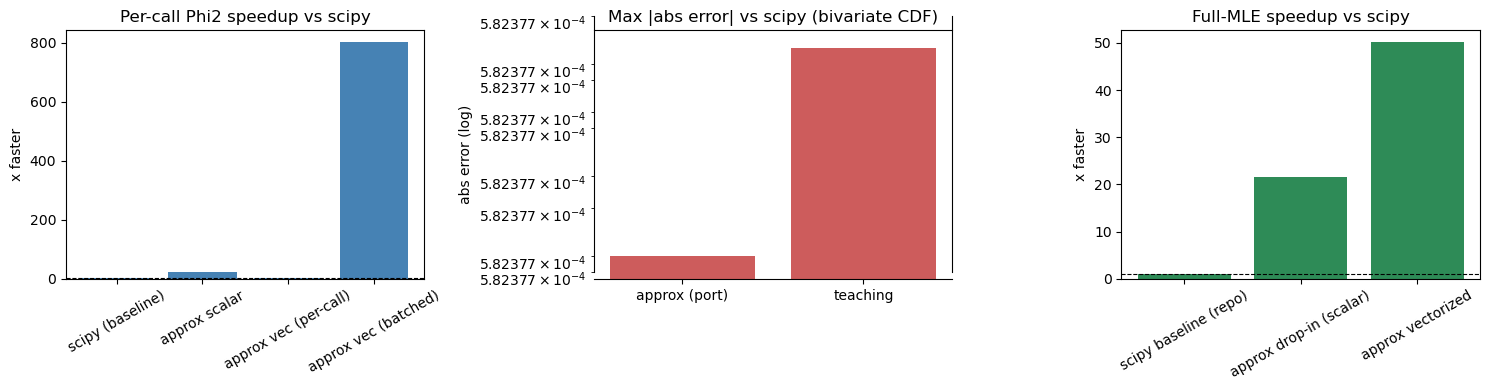

In [12]:
mle_tbl = pd.DataFrame({
    'MLE method': ['scipy baseline (repo)', 'approx drop-in (scalar)', 'approx vectorized'],
    'sigma_hat': [res_scipy['sigma_hat'], res_approx['sigma_hat'], s_ap_vec],
    'seconds': [t_mle_scipy, t_mle_approx, t_ap_vec],
})
mle_tbl['speedup_x'] = t_mle_scipy / mle_tbl['seconds']
mle_tbl['d_sigma_vs_scipy'] = (mle_tbl['sigma_hat'] - res_scipy['sigma_hat']).abs()
print('sigma_true =', SIGMA_TRUE)
print('PER-CALL Phi_2 (us/call):'); print(per_call.to_string(index=False)); print()
print('LOOP-LEVEL pairwise loglik, m=%d (ms/step):' % m); print(loop_tbl.to_string(index=False)); print()
print('FULL MLE of sigma:'); print(mle_tbl.to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(per_call['method'], per_call['speedup_x'], color='steelblue'); ax[0].set_title('Per-call Phi2 speedup vs scipy')
ax[0].set_ylabel('x faster'); ax[0].tick_params(axis='x', rotation=30); ax[0].axhline(1, color='k', lw=0.8, ls='--')
ax[1].bar(['approx (port)', 'teaching'], [max_port, max_teach], color='indianred')
ax[1].set_yscale('log'); ax[1].set_title('Max |abs error| vs scipy (bivariate CDF)'); ax[1].set_ylabel('abs error (log)')
ax[2].bar(mle_tbl['MLE method'], mle_tbl['speedup_x'], color='seagreen'); ax[2].set_title('Full-MLE speedup vs scipy')
ax[2].set_ylabel('x faster'); ax[2].tick_params(axis='x', rotation=30); ax[2].axhline(1, color='k', lw=0.8, ls='--')
plt.tight_layout(); plt.show()

## 10. Conclusion

Measured on this machine (absolute numbers are machine-dependent; the ratios are the
point):

- What the method is. One idea: in the exact 1-D integral
  $\Phi_2(p,q;\rho)=\int_{-\infty}^{q}\varphi(\nu)\,\Phi(a\nu+b)\,d\nu$ (paper Eqs.
  4–5), replace the inner normal CDF by `Phi_approx` (the cornerstone
  $\operatorname{erf}\approx g$, two fitted constants). Doing the resulting integral
  analytically gives Theorem 1's closed form $F_\text{app}$, and the five cases are
  just the sign-bookkeeping of that one integral. `bvn_teaching` is the transparent
  version; the vectorised `phi2_approxcdf_vec` is the same $F_\text{app}$
  pre-expanded into four branches and made fast. They agree to machine precision.
- Accuracy. $F_\text{app}$ matches scipy's bivariate CDF to $\sim10^{-3}$ (Part 1).
  That tiny CDF error barely moves the estimate: here $\hat\sigma$ from the
  approximate fit differs from the scipy fit by $\sim10^{-5}$, negligible for an
  internal range parameter.
- Speed. Being a branch-free `erf` closed form, it is far faster than the per-call
  scipy object, most of all when batched, and being closed-form in $\rho$ it
  vectorises over per-pair $\rho$.

Takeaway: the biggest, safest win is structural and backend-agnostic, a vectorised
$\Phi_2$ kernel together with the `np.triu_indices` rewrite of the pair loop. For the
kernel itself, the Tsay–Ke approximation gives $\sim10^{-3}$ CDF error with
$\hat\sigma$ essentially unchanged, at the cost of nothing but the few lines of
pure-NumPy above (no extra dependency).